In [40]:
import os, json, glob, gzip
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

In [41]:
KAGGLE_BASE = '/kaggle/input/datasets/qwerte123/hetero-data-updated-diffemb'
LOCAL_BASE  = r'C:\Users\Admin\Documents\GitHub\claude_plum\data'
BASE        = KAGGLE_BASE if os.path.exists(KAGGLE_BASE) else LOCAL_BASE

DATA_PATH     = os.path.join(BASE, 'heterodata_object12_updated.pt')
META_PATH     = os.path.join(BASE, 'meta.json.gz')
DMAP_PATH     = os.path.join(BASE, 'datamaps.json')
BASELINE_PATH = os.path.join(BASE, 'best_rqvae.pth')
CKPT_DIR_IMP  = os.path.join(BASE, 'checkpoints_improved')
CKPT_DIR_ANTI = os.path.join(BASE, 'checkpoints_anti')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

df = torch.load(DATA_PATH, weights_only=False, map_location='cpu')
df

device: cpu


HeteroData(
  item={
    x=[12101, 100],
    text=[12101, 2],
    related=[12101],
    is_train=[12101],
  },
  (user, rated, item)={
    history={
      train={
        item_ID=[22363],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      valid={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      test={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
    },
  }
)

In [42]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        dims = [input_dim] + list(hidden_dims) + [output_dim]
        for i, (in_d, out_d) in enumerate(zip(dims[:-1], dims[1:])):
            layers.append(nn.Linear(in_d, out_d, bias=True))
            if i < len(dims) - 2:
                layers.append(nn.LayerNorm(out_d))
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class EMACodebook(nn.Module):
    def __init__(self, codebook_size, emb_dim, beta=0.25, ema_decay=0.99, epsilon=1e-4):
        super().__init__()
        self.codebook_size = codebook_size
        self.beta          = beta
        self.ema_decay     = ema_decay
        self.epsilon       = epsilon
        emb = F.normalize(torch.randn(codebook_size, emb_dim), p=2, dim=1)
        self.register_buffer('emb',         emb)
        self.register_buffer('ema_count',   torch.ones(codebook_size))
        self.register_buffer('ema_weight',  emb.clone())
        self.register_buffer('initialized', torch.zeros(1, dtype=torch.bool))

    def forward(self, x):
        x_n    = F.normalize(x,        p=2, dim=1)
        code_n = F.normalize(self.emb, p=2, dim=1)
        dist   = 1.0 - x_n @ code_n.T
        ids    = dist.argmin(dim=1)
        emb    = self.emb[ids]
        commitment_loss = self.beta * F.mse_loss(x, emb.detach())
        emb_st = x + (emb - x).detach()
        return commitment_loss, emb_st, ids


class RQVAE_Improved(nn.Module):
    def __init__(self, inp_size, hidden_sizes, embed_dim, n_layers,
                 codebook_size=256, beta=0.25, gamma=0.1,
                 ema_decay=0.99, temperature=0.07):
        super().__init__()
        self.n_layers    = n_layers
        self.gamma       = gamma
        self.temperature = temperature

        self.enc = Encoder(inp_size,   hidden_sizes,           embed_dim)
        self.dec = Encoder(embed_dim,  hidden_sizes[::-1],     inp_size)
        self.codebooks = nn.ModuleList([
            EMACodebook(codebook_size, embed_dim, beta=beta, ema_decay=ema_decay)
            for _ in range(n_layers)
        ])

    def forward(self, x, related, is_self_pair=None):
        x_n = F.normalize(x,       p=2, dim=1)
        r_n = F.normalize(related, p=2, dim=1)

        encoded = self.enc(x_n)
        rel_encoded = self.enc(r_n)

        if self.training:
            level_mask = torch.randint(1, self.n_layers + 1, (1,)).item()
        else:
            level_mask = self.n_layers

        r = encoded
        e_sum = torch.zeros_like(encoded)
        q_losses = x.new_zeros([])
        sids = []

        for level, cb in enumerate(self.codebooks):
            q_loss, emb_st, ids = cb(r)
            r = r - emb_st.detach()     
            sids.append(ids)
            if level < level_mask:      
                q_losses = q_losses + q_loss
                e_sum    = e_sum    + emb_st

        dec = self.dec(e_sum)
        rec_loss = F.mse_loss(x_n, dec)

        enc_n = F.normalize(encoded, p=2, dim=1)
        rel_n = F.normalize(rel_encoded, p=2, dim=1)
        sims = (enc_n @ rel_n.T) /self.temperature   
        log_p = F.log_softmax(sims, dim=1)
        diag  = -torch.diag(log_p)                     

        if is_self_pair is not None:
            valid = ~is_self_pair
            con_loss = diag[valid].mean() if valid.any() else x.new_zeros([])
        else:
            con_loss = diag.mean()

        loss = q_losses + rec_loss + self.gamma * con_loss

        return {
            'loss': loss,
            'q_loss': q_losses,
            'r_loss': rec_loss,
            'con_loss': con_loss,
            'sids': sids,
            'level_mask': level_mask,
        }

class Data_Embeddings(Dataset):
    def __init__(self, embed, related):
        self.embed   = embed
        self.related = related
    def __len__(self):
        return self.embed.shape[0]
    def __getitem__(self, index):
        rel_ids = self.related[index]
        if len(rel_ids) == 0:
            rel_embed, is_self = self.embed[index], True
        else:
            rel_embed, is_self = self.embed[int(np.random.choice(rel_ids))], False
        return rel_embed, self.embed[index], torch.tensor(is_self)

In [43]:
class RQVAE_AntiContrastive(nn.Module):
    """
    RQ-VAE where the auxiliary loss REPELS related items instead of attracting them.

    Anti-contrastive loss:
        sim_i  = cos_sim( enc(x_i), enc(x_related_i) )   # scalar per sample
        L_anti = mean( ReLU( sim_i + margin ) )            # penalise sim > -margin

    With margin=0.5 we want every related pair to be at cosine similarity < -0.5.
    Once separated enough the gradient is zero (hinge / no further push).

    Effect on SIDs: related items land far apart on the unit sphere → they are
    assigned to distinct codebook entries → fewer collisions.
    """
    def __init__(self, inp_size, hidden_sizes, embed_dim, n_layers,
                 codebook_size=256, beta=0.25, gamma=0.1,
                 ema_decay=0.99, margin=0.5):
        super().__init__()
        self.n_layers = n_layers
        self.gamma    = gamma
        self.margin   = margin

        self.enc = Encoder(inp_size,  hidden_sizes,        embed_dim)
        self.dec = Encoder(embed_dim, hidden_sizes[::-1],  inp_size)
        self.codebooks = nn.ModuleList([
            EMACodebook(codebook_size, embed_dim, beta=beta, ema_decay=ema_decay)
            for _ in range(n_layers)
        ])

    def forward(self, x, related, is_self_pair=None):
        x_n = F.normalize(x,       p=2, dim=1)
        r_n = F.normalize(related, p=2, dim=1)

        encoded     = self.enc(x_n)
        rel_encoded = self.enc(r_n)

        if self.training:
            level_mask = torch.randint(1, self.n_layers + 1, (1,)).item()
        else:
            level_mask = self.n_layers

        r        = encoded
        e_sum    = torch.zeros_like(encoded)
        q_losses = x.new_zeros([])
        sids     = []

        for level, cb in enumerate(self.codebooks):
            q_loss, emb_st, ids = cb(r)
            r = r - emb_st.detach()
            sids.append(ids)
            if level < level_mask:
                q_losses = q_losses + q_loss
                e_sum    = e_sum    + emb_st

        dec      = self.dec(e_sum)
        rec_loss = F.mse_loss(x_n, dec)

        enc_n = F.normalize(encoded, p=2, dim=1)
        rel_n = F.normalize(rel_encoded, p=2, dim=1)
        sim   = (enc_n * rel_n).sum(dim=1)              
        anti_loss_per_item = F.relu(sim + self.margin)  
        if is_self_pair is not None:
            valid = ~is_self_pair
            anti_loss = anti_loss_per_item[valid].mean() if valid.any() else x.new_zeros([])
        else:
            anti_loss = anti_loss_per_item.mean()

        loss = q_losses + rec_loss + self.gamma * anti_loss

        return {
            'loss':       loss,
            'q_loss':     q_losses,
            'r_loss':     rec_loss,
            'con_loss':   anti_loss,   
            'sids':       sids,
            'level_mask': level_mask,
        }

In [44]:
class _BaseCodebook(nn.Module):
    def __init__(self, codebook_size, emb_dim, beta):
        super().__init__()
        self.beta = beta
        self.emb  = nn.Embedding(codebook_size, emb_dim)
        nn.init.uniform_(self.emb.weight, -1.0, 1.0)
    def forward(self, x):
        code = self.emb.weight
        dist = (x**2).sum(1, keepdim=True) + (code**2).sum(1) - 2 * x @ code.T
        ids  = dist.argmin(1)
        emb  = self.emb(ids)
        loss = F.mse_loss(emb, x.detach()) + self.beta * F.mse_loss(x, emb.detach())
        return loss, x + (emb - x).detach(), ids

class _BaseEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        dims, layers = [input_dim]+hidden_dims+[output_dim], []
        for i, (a, b) in enumerate(zip(dims[:-1], dims[1:])):
            layers.append(nn.Linear(a, b, bias=False))
            if i < len(dims)-2: layers.append(nn.ReLU())
        self.encoder = nn.Sequential(*layers)   
    def forward(self, x): return self.encoder(x)

class RQVAE_Baseline(nn.Module):
    def __init__(self, inp_size, hidden_sizes, embed_dim, n_codebooks, n_layers, beta):
        super().__init__()
        self.emb_dim = embed_dim
        self.enc = _BaseEncoder(inp_size, hidden_sizes, embed_dim)
        self.dec = _BaseEncoder(embed_dim, hidden_sizes[::-1], inp_size)
        self.layers = nn.ModuleList([
            _BaseCodebook(n_codebooks, embed_dim, beta) for _ in range(n_layers)
        ])
    def forward(self, x):
        encoded = self.enc(x)
        r, q_losses, sids = encoded, 0, []
        e_sum = torch.zeros(x.shape[0], self.emb_dim, device=x.device)
        for layer in self.layers:
            q_loss, emb, ids = layer(r)
            r = r - emb.detach()
            q_losses += q_loss; e_sum += emb; sids.append(ids)
        dec = self.dec(e_sum)
        rec_loss = F.mse_loss(x, dec)
        return {'sids': sids, 'q_loss': q_losses, 'r_loss': rec_loss,
                'loss': q_losses + rec_loss}

In [45]:
def unique_per_level(sids):
    return torch.tensor([s.unique().numel() for s in sids])

def entropy_per_level(all_sids, codebook_size):
    out = []
    for level_ids in all_sids:
        ids = torch.cat(level_ids).view(-1)
        counts = torch.bincount(ids, minlength=codebook_size).float()
        probs = counts / counts.sum()
        probs = probs[probs > 0]
        out.append(-(probs * probs.log2()).sum())
    return torch.stack(out).cpu()

def sids_analyze_baseline(model, ds, device):    
    model.eval()
    sid_to_ids = defaultdict(list)
    id_to_sid  = {}
    total_loss = 0.0
    with torch.no_grad():
        for item_id in range(len(ds)):
            _, emb, _ = ds[item_id]          # related и is_self не нужны
            out = model(emb.to(device).unsqueeze(0))
            sid = tuple(s.item() for s in out['sids'])
            sid_to_ids[sid].append(item_id)
            id_to_sid[item_id] = sid
            total_loss += out['loss'].item()

    id_to_fullsid = {}
    for sid, ids in sid_to_ids.items():
        for cnt, iid in enumerate(ids):
            id_to_fullsid[iid] = sid if len(ids) == 1 else (*sid, cnt)

    return {'id_to_sid': id_to_sid, 'sid_to_ids': sid_to_ids,
              'id_to_fullsid': id_to_fullsid,
              'total_loss': total_loss / len(ds)}

def sids_analyze(model, ds, device):
    model.eval()
    sid_to_ids = defaultdict(list)
    id_to_sid  = {}
    total_loss = 0.0
    with torch.no_grad():
        for item_id in range(len(ds)):
            rel_emb, emb, is_self = ds[item_id]
            emb = emb.to(device).unsqueeze(0)
            rel_emb = rel_emb.to(device).unsqueeze(0)
            out = model(emb, rel_emb, is_self.unsqueeze(0))
            sid = tuple(s.item() for s in out['sids'])
            sid_to_ids[sid].append(item_id)
            id_to_sid[item_id] = sid
            total_loss += out['loss'].item()

    id_to_fullsid = {}
    for sid, ids in sid_to_ids.items():
        for cnt, iid in enumerate(ids):
            id_to_fullsid[iid] = sid if len(ids) == 1 else (*sid, cnt)

    return {'id_to_sid': id_to_sid, 'sid_to_ids': sid_to_ids,
            'id_to_fullsid': id_to_fullsid,
            'total_loss': total_loss / len(ds)}
    
def calculate_pas(sid_to_ids, embeddings):                                                                                                                  
      sims = []
      emb = F.normalize(embeddings, p=2, dim=1)  
      for ids in sid_to_ids.values():
          if len(ids) < 2:
              continue
          vecs = emb[ids]                         
          sim_matrix = vecs @ vecs.T            
          k = len(ids)
          idx = torch.triu_indices(k, k, offset=1)
          sims.append(sim_matrix[idx[0], idx[1]])

      if not sims:
          return float('nan')   

      return torch.cat(sims).mean().item()

  
def calculate_metrics(sid_to_ids, n_items, embeddings, codebook_size, n_layers):
    n_colls = sum(len(v) - 1 for v in sid_to_ids.values())
        
    return {
        'Number unique sids': len(sid_to_ids),
        'Number collisions': n_colls,
        'Max Cluster size': max(len(v) for v in sid_to_ids.values()),
        'Independent Code Rate': len(sid_to_ids)/n_items,
        'Path Average Similarity': calculate_pas(sid_to_ids, embeddings),
        'CUR_total': len(sid_to_ids)/codebook_size**n_layers
    }

In [46]:
embeds  = df['item'].x
related = df['item'].related
ds      = Data_Embeddings(embeds, related)
n_items = len(ds)
print(f'Items: {n_items}')

Items: 12101


In [47]:
import glob as _glob
ckpts = sorted(_glob.glob(os.path.join(CKPT_DIR_IMP, 'rqvae_improved_s*.pt')))
assert ckpts, f'No checkpoint found in {CKPT_DIR_IMP}'
ckpt_path = ckpts[-1]
print(f'Loading: {ckpt_path}')

ckpt   = torch.load(ckpt_path, map_location=device, weights_only=False)
hp     = ckpt['hparams']
print('Hparams:', hp)
print(f'Sessions completed: {ckpt["session"]}')
print(f'Epochs trained: {len(ckpt["history"]["train_loss"])}')

model_imp = RQVAE_Improved(
    inp_size      = embeds.shape[1],
    hidden_sizes  = [1024, 512, 256, 128],
    embed_dim     = hp['embed_dim'],
    n_layers      = hp['n_layers'],
    codebook_size = hp['codebook_size'],
    beta          = hp['beta'],
    gamma         = hp['gamma'],
    ema_decay     = hp['ema_decay'],
    temperature   = hp['temperature'],
).to(device)
model_imp.load_state_dict(ckpt['model_state'])
model_imp.eval()
print('RQVAE_Improved loaded.')

Loading: C:\Users\Admin\Documents\GitHub\claude_plum\data\checkpoints_improved\rqvae_improved_s5.pt
Hparams: {'n_layers': 4, 'codebook_size': 256, 'embed_dim': 32, 'beta': 0.25, 'gamma': 0.1, 'ema_decay': 0.99, 'temperature': 0.07, 'lr': 0.001}
Sessions completed: 5
Epochs trained: 838
RQVAE_Improved loaded.


In [48]:
ckpts_anti = sorted(glob.glob(os.path.join(CKPT_DIR_ANTI, 'rqvae_anti_s*.pt')))
model_anti = None
ckpt_anti  = None

if not ckpts_anti:
    print('WARNING: No anti-contrastive checkpoint found — skipping anti model.')
else:
    ckpt_anti = torch.load(ckpts_anti[-1], map_location=device, weights_only=False)
    hp_anti   = ckpt_anti['hparams']
    print(f'Loading: {ckpts_anti[-1]}')
    print('Hparams:', hp_anti)
    print(f'Sessions completed: {ckpt_anti["session"]}')

    model_anti = RQVAE_AntiContrastive(
        inp_size      = embeds.shape[1],
        hidden_sizes  = [1024, 512, 256, 128],
        embed_dim     = hp_anti['embed_dim'],
        n_layers      = hp_anti['n_layers'],
        codebook_size = hp_anti['codebook_size'],
        beta          = hp_anti['beta'],
        gamma         = hp_anti['gamma'],
        ema_decay     = hp_anti['ema_decay'],
        margin        = hp_anti['margin'],
    ).to(device)
    model_anti.load_state_dict(ckpt_anti['model_state'])
    model_anti.eval()
    print('RQVAE_AntiContrastive loaded.')

Loading: C:\Users\Admin\Documents\GitHub\claude_plum\data\checkpoints_anti\rqvae_anti_s5.pt
Hparams: {'n_layers': 4, 'codebook_size': 256, 'embed_dim': 32, 'beta': 0.25, 'gamma': 0.05, 'margin': 0.3, 'ema_decay': 0.99, 'temperature': 0.07, 'lr': 0.001}
Sessions completed: 5
RQVAE_AntiContrastive loaded.


In [49]:
model_base = RQVAE_Baseline(
    inp_size=embeds.shape[1], hidden_sizes=[512,256,128],
    embed_dim=32, n_codebooks=2048, n_layers=3, beta=0.25
).to(device)
model_base.load_state_dict(torch.load(BASELINE_PATH, map_location=device))
model_base.eval()
print('RQVAE_Baseline loaded.')

RQVAE_Baseline loaded.


In [50]:
print('Analyzing RQVAE_Baseline ...')
res_base = sids_analyze_baseline(model_base, ds, device)

print('Analyzing RQVAE_Improved ...')
res_imp  = sids_analyze(model_imp,  ds, device)

res_anti = None
if model_anti is not None:
    print('Analyzing RQVAE_AntiContrastive ...')
    res_anti = sids_analyze(model_anti, ds, device)  

m_base = calculate_metrics(res_base['sid_to_ids'], n_items, embeds, 
                            32, 3)
m_imp  = calculate_metrics(res_imp['sid_to_ids'], n_items, embeds, 
                            hp['codebook_size'], hp['n_layers'])

rows = {'RQVAE_Baseline': m_base, 'RQVAE_Improved': m_imp}
if res_anti is not None:
    rows['RQVAE_AntiContrastive'] = calculate_metrics(res_anti['sid_to_ids'], n_items, embeds,
                                                      hp_anti['codebook_size'], hp_anti['n_layers'])

cmp = pd.DataFrame(rows).T
print(cmp.to_string())

Analyzing RQVAE_Baseline ...
Analyzing RQVAE_Improved ...
Analyzing RQVAE_AntiContrastive ...
                       Number unique sids  Number collisions  Max Cluster size  Independent Code Rate  Path Average Similarity  CUR_total
RQVAE_Baseline                    11092.0             1009.0               9.0               0.916618                 0.803977   0.338501
RQVAE_Improved                    11754.0              347.0               6.0               0.971325                 0.983277   0.000003
RQVAE_AntiContrastive             10311.0             1790.0              21.0               0.852078                 0.939252   0.000002


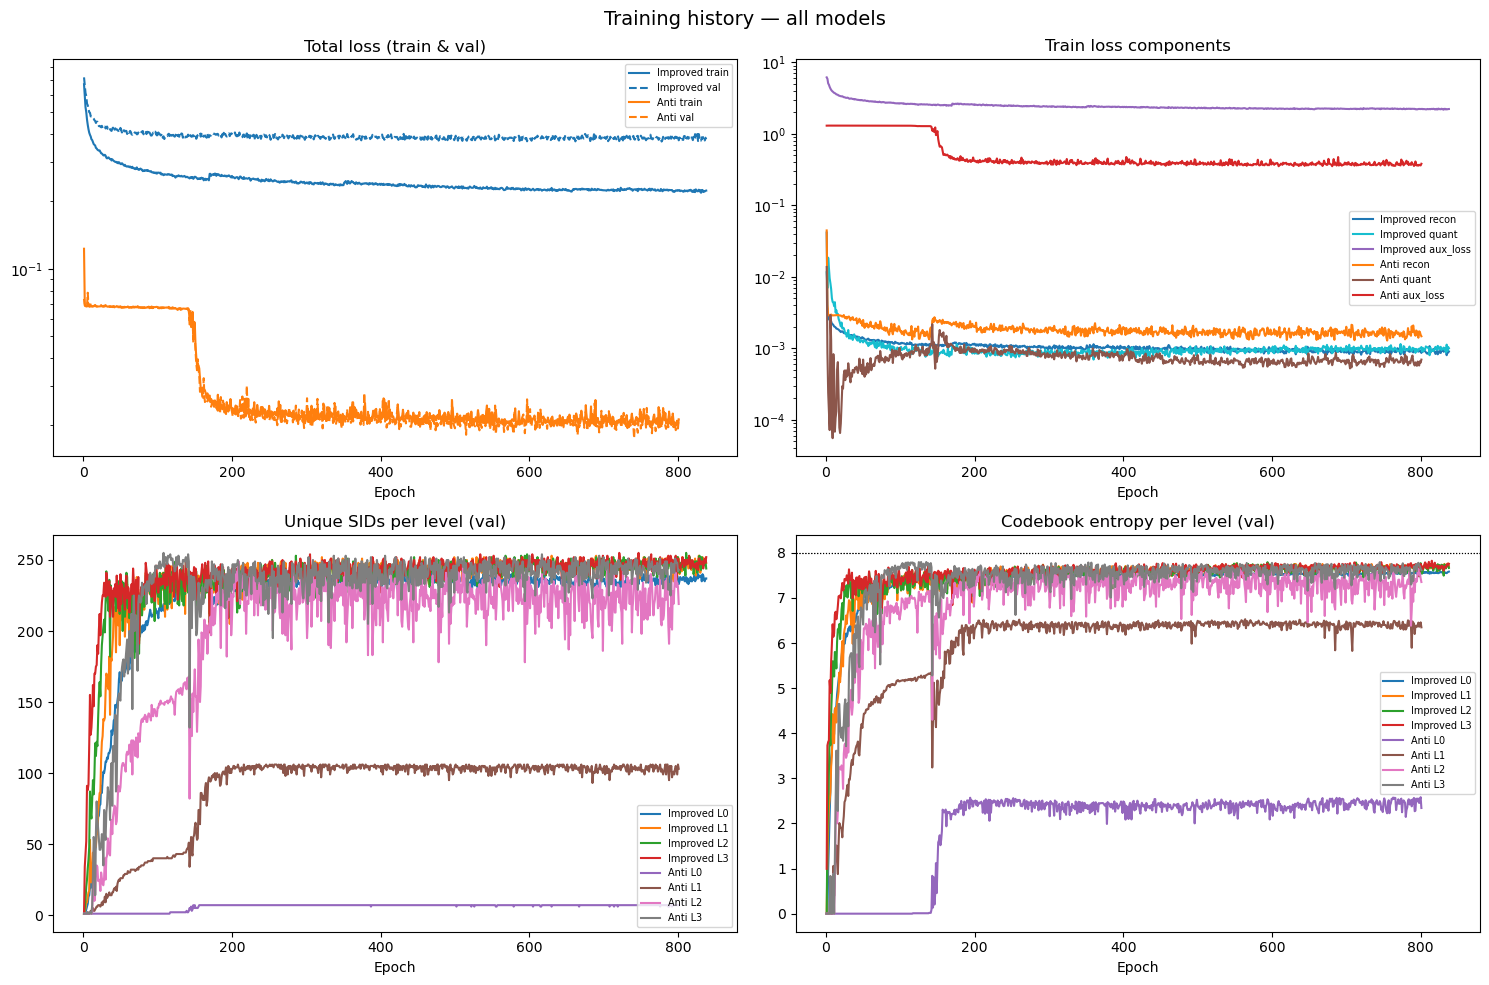

In [51]:
def plot_training_curves(ckpt, label, color_prefix, axes):
    history = ckpt['history']
    epochs  = range(1, len(history['train_loss']) + 1)
    hp      = ckpt['hparams']

    axes[0,0].plot(epochs, history['train_loss'], label=f'{label} train', color=color_prefix[0])
    axes[0,0].plot(epochs, history['val_loss'],   label=f'{label} val',   color=color_prefix[0], ls='--')

    axes[0,1].plot(epochs, history['train_r_loss'],   label=f'{label} recon',     color=color_prefix[0])
    axes[0,1].plot(epochs, history['train_q_loss'],   label=f'{label} quant',     color=color_prefix[1])
    axes[0,1].plot(epochs, history['train_con_loss'], label=f'{label} aux_loss',  color=color_prefix[2])

    sids_va = np.array([t.numpy() for t in history['val_sids_num']])
    for lvl in range(sids_va.shape[1]):
        axes[1,0].plot(epochs, sids_va[:, lvl], label=f'{label} L{lvl}')

    ent_va = np.array([t.numpy() for t in history['val_entropy']])
    for lvl in range(ent_va.shape[1]):
        axes[1,1].plot(epochs, ent_va[:, lvl], label=f'{label} L{lvl}')
    axes[1,1].axhline(np.log2(hp['codebook_size']), color='k', ls=':', lw=0.8)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Training history — all models', fontsize=14)

plot_training_curves(ckpt,      'Improved', ['tab:blue',  'tab:cyan',   'tab:purple'], axes)
if ckpt_anti is not None:
    plot_training_curves(ckpt_anti, 'Anti',     ['tab:orange', 'tab:brown',  'tab:red'],    axes)

for ax in axes[0]: ax.set_yscale('log'); ax.legend(fontsize=7); ax.set_xlabel('Epoch')
axes[0,0].set_title('Total loss (train & val)')
axes[0,1].set_title('Train loss components')
axes[1,0].set_title('Unique SIDs per level (val)'); axes[1,0].legend(fontsize=7); axes[1,0].set_xlabel('Epoch')
axes[1,1].set_title('Codebook entropy per level (val)'); axes[1,1].legend(fontsize=7); axes[1,1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('analysis_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

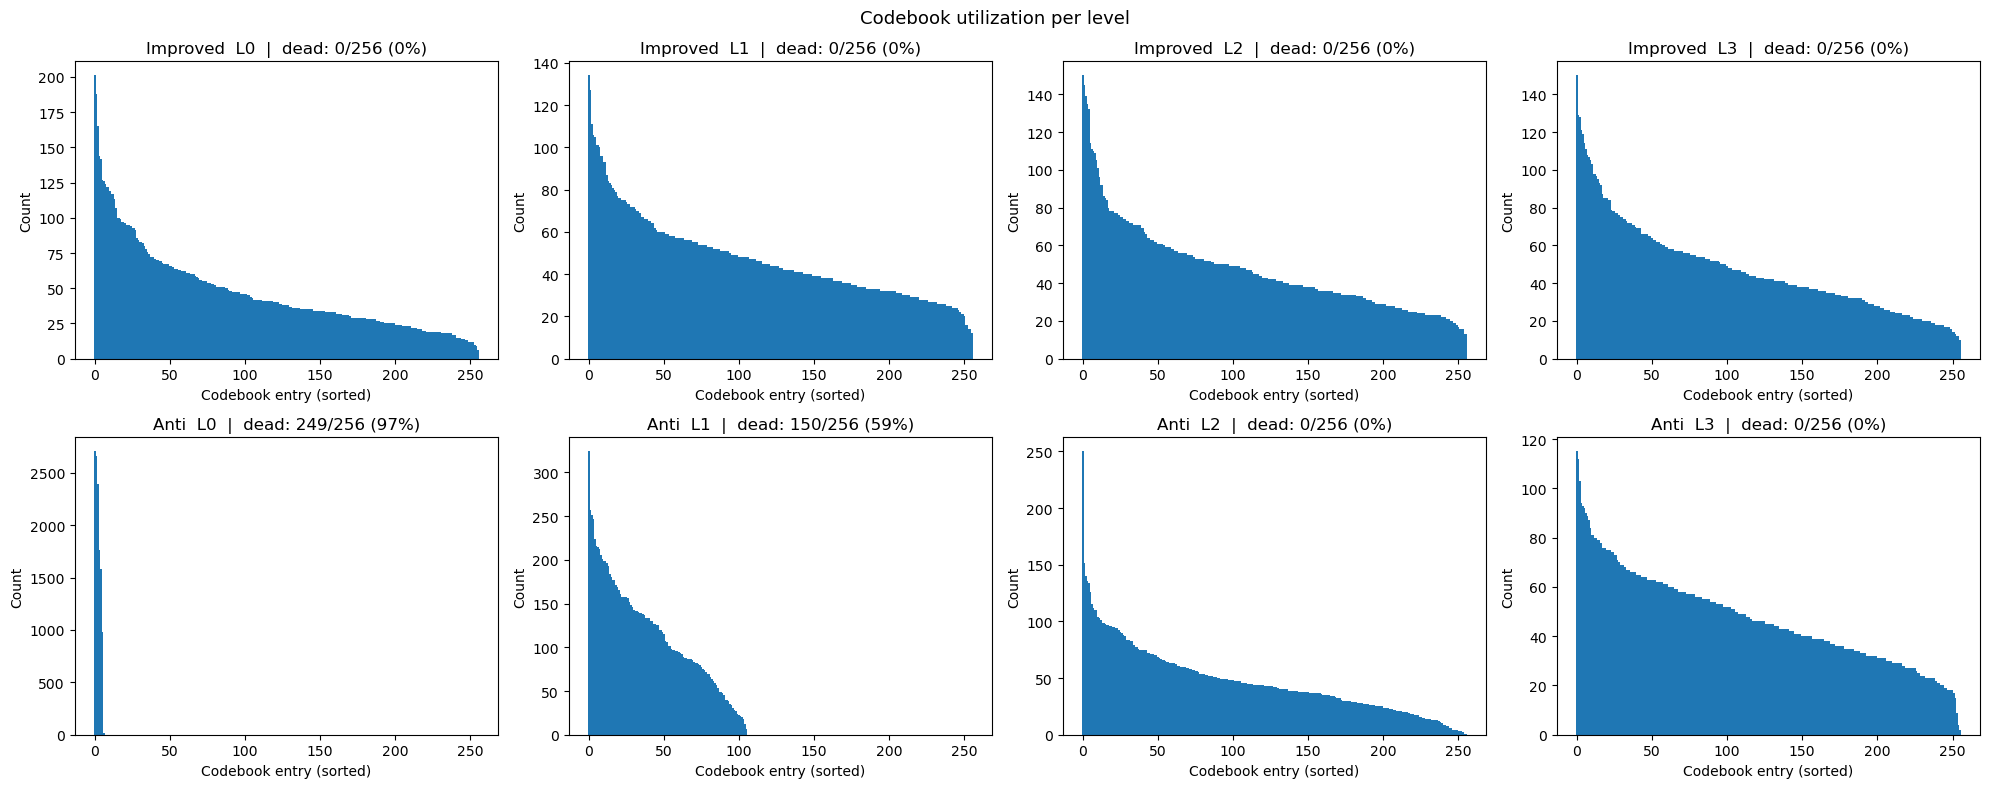

In [52]:
def codebook_utilization(model, ds, device):
    model.eval()
    counts = [torch.zeros(cb.codebook_size) for cb in model.codebooks]
    with torch.no_grad():
        for i in range(len(ds)):
            rel_emb, emb, is_self = ds[i]
            out = model(emb.to(device).unsqueeze(0),
                        rel_emb.to(device).unsqueeze(0),
                        is_self.unsqueeze(0))
            for lvl, sid in enumerate(out['sids']):
                counts[lvl][sid.item()] += 1
    return counts

models_to_plot = [('Improved', model_imp, hp)]
if model_anti is not None:
    models_to_plot.append(('Anti', model_anti, hp_anti))

n_models = len(models_to_plot)
n_levels = hp['n_layers']
cs       = hp['codebook_size']

fig, axes = plt.subplots(n_models, n_levels, figsize=(5 * n_levels, 4 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]
fig.suptitle('Codebook utilization per level', fontsize=13)

for row, (label, mdl, hparams) in enumerate(models_to_plot):
    util = codebook_utilization(mdl, ds, device)
    for lvl, cnt in enumerate(util):
        ax  = axes[row, lvl]
        cnt_sorted = cnt.sort(descending=True).values.numpy()
        ax.bar(range(len(cnt_sorted)), cnt_sorted, width=1.0)
        dead = (cnt == 0).sum().item()
        ax.set_title(f'{label}  L{lvl}  |  dead: {dead}/{cs} ({100*dead/cs:.0f}%)')
        ax.set_xlabel('Codebook entry (sorted)')
        ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('analysis_codebook_utilization.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
with open(DMAP_PATH) as f:
    maps = json.load(f)
asin2id = {a: int(i)-1 for a, i in maps['item2id'].items()}

item_subcat = {}
with gzip.open(META_PATH, 'r') as f:
    for line in f:
        meta  = eval(line)
        asin  = meta.get('asin', '')
        if asin not in asin2id: continue
        path  = meta.get('categories', [[]])
        path  = path[0] if path else []
        subcat = path[1] if len(path) > 1 else (path[0] if path else 'Unknown')
        item_subcat[asin2id[asin]] = subcat

subcats = [item_subcat.get(i, 'Unknown') for i in range(n_items)]
print(pd.Series(subcats).value_counts())

Skin Care              3814
Hair Care              3262
Makeup                 2627
Tools & Accessories    1222
Bath & Body             684
Fragrance               492
Name: count, dtype: int64


In [54]:
print(len(set(subcats)), subcats[:10])

6 ['Makeup', 'Makeup', 'Skin Care', 'Makeup', 'Skin Care', 'Skin Care', 'Makeup', 'Skin Care', 'Skin Care', 'Skin Care']


In [55]:
def make_viz_df(sid_results, subcats):
    id_to_sid = sid_results['id_to_sid']
    return pd.DataFrame({
        'subcat': subcats,
        'c1': [id_to_sid[i][0] for i in range(len(subcats))],
        'c2': [id_to_sid[i][1] for i in range(len(subcats))],
    })

viz_base = make_viz_df(res_base, subcats)
viz_imp  = make_viz_df(res_imp,  subcats)
viz_anti = make_viz_df(res_anti, subcats) if res_anti is not None else None

In [56]:
viz_imp

,subcat,c1,c2
0,Makeup,223,152
1,Makeup,223,12
2,Skin Care,166,106
3,Makeup,194,100
4,Skin Care,81,250
...,...,...,...
12096,Skin Care,210,65
12097,Skin Care,151,158
12098,Skin Care,151,158
12099,Skin Care,151,158


In [57]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def collect_enc_and_codes(model, ds, device):
    model.eval()
    all_enc, all_codes = [], []
    with torch.no_grad():
        for i in range(len(ds)):
            rel_emb, emb, is_self = ds[i]
            x    = emb.to(device).unsqueeze(0)
            x_in = F.normalize(x, p=2, dim=1)
            enc  = model.enc(x_in).squeeze(0).cpu()
            out  = model(x, rel_emb.to(device).unsqueeze(0), is_self.unsqueeze(0))
            all_enc.append(enc)
            all_codes.append([s.item() for s in out['sids']])
    return torch.stack(all_enc).numpy(), np.array(all_codes)  # (N, D), (N, L)

def run_tsne(matrix, perplexity=40, n_iter=1000):
    print(f'  t-SNE {matrix.shape} → (N, 2)...')
    return TSNE(n_components=2, random_state=42, perplexity=perplexity,
                init='pca').fit_transform(matrix)

def make_rgb_table(model, lvl):
    """Вариант B: PCA(3) на векторах кодбука -> уникальный RGB для каждого кода."""
    codebook = model.codebooks[lvl].emb.detach().cpu().numpy()  
    pca = PCA(n_components=3).fit_transform(codebook)           
    pca -= pca.min(axis=0)
    pca /= pca.max(axis=0) + 1e-8
    return pca.astype(np.float32)                              

def scatter_coded(ax, proj, code_ids, title):
    """Оригинальный вариант: tab20 по модулю 20."""
    colors = plt.cm.get_cmap('tab20')(code_ids % 20)
    ax.scatter(proj[:, 0], proj[:, 1], c=colors, s=3, alpha=0.4, linewidths=0)
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

def scatter_rgb(ax, proj, code_ids, rgb_table, title):
    """Вариант B: уникальный RGB из PCA кодбука."""
    colors = rgb_table[code_ids]                 
    ax.scatter(proj[:, 0], proj[:, 1], c=colors, s=3, alpha=0.4, linewidths=0)
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

def scatter_categorical(ax, proj, cat_ids, cat_names, title):
    """Вариант 3: цвет = категория товара."""
    cmap = plt.cm.get_cmap('tab10', len(cat_names))
    for i, name in enumerate(cat_names):
        mask = cat_ids == i
        ax.scatter(proj[mask, 0], proj[mask, 1], c=[cmap(i)],
                   s=3, alpha=0.5, linewidths=0, label=name)
    ax.legend(markerscale=4, fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

def make_grid(L):
    """Возвращает (rows, cols) для сетки L графиков в 2 ряда."""
    cols = (L + 1) // 2
    return 2, cols

cat_names = sorted(set(subcats))
cat_to_id = {c: i for i, c in enumerate(cat_names)}
cat_ids   = np.array([cat_to_id[s] for s in subcats])

models_viz = [('Improved', model_imp)]
if model_anti is not None:
    models_viz.append(('Anti', model_anti))

print('Computing shared input-space t-SNE...')
proj_input = run_tsne(F.normalize(embeds.float(), p=2, dim=1).numpy())
print('Done.')

Computing shared input-space t-SNE...
  t-SNE (12101, 100) → (N, 2)...
Done.


In [58]:
print('RQVAE_Improved: collecting encoder embeddings...')
enc_mat_imp, codes_imp = collect_enc_and_codes(model_imp, ds, device)
proj_enc_imp = run_tsne(enc_mat_imp)
print('Done.')

RQVAE_Improved: collecting encoder embeddings...
  t-SNE (12101, 32) → (N, 2)...
Done.


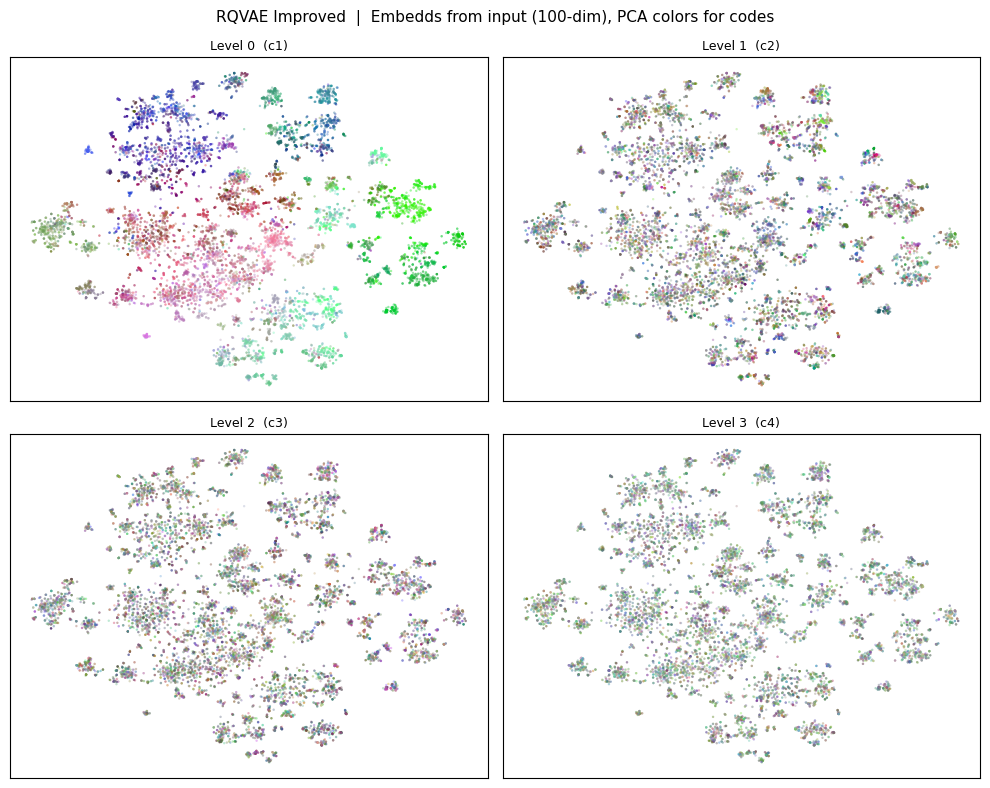

In [71]:
L = model_imp.n_layers
rows, cols = make_grid(L)
rgb_tables_imp = [make_rgb_table(model_imp, lvl) for lvl in range(L)]

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
fig.suptitle('RQVAE Improved  |  Embedds from input (100-dim), PCA colors for codes', fontsize=11)
axs = axes.flatten()
for lvl in range(L):
     scatter_rgb(axs[lvl], proj_input, codes_imp[:, lvl], rgb_tables_imp[lvl],  f'Level {lvl}  (c{lvl+1})')
for i in range(L, len(axs)): axs[i].axis('off')
plt.tight_layout()
plt.savefig('imp_v1_input_by_code.png', dpi=150, bbox_inches='tight')
plt.show()



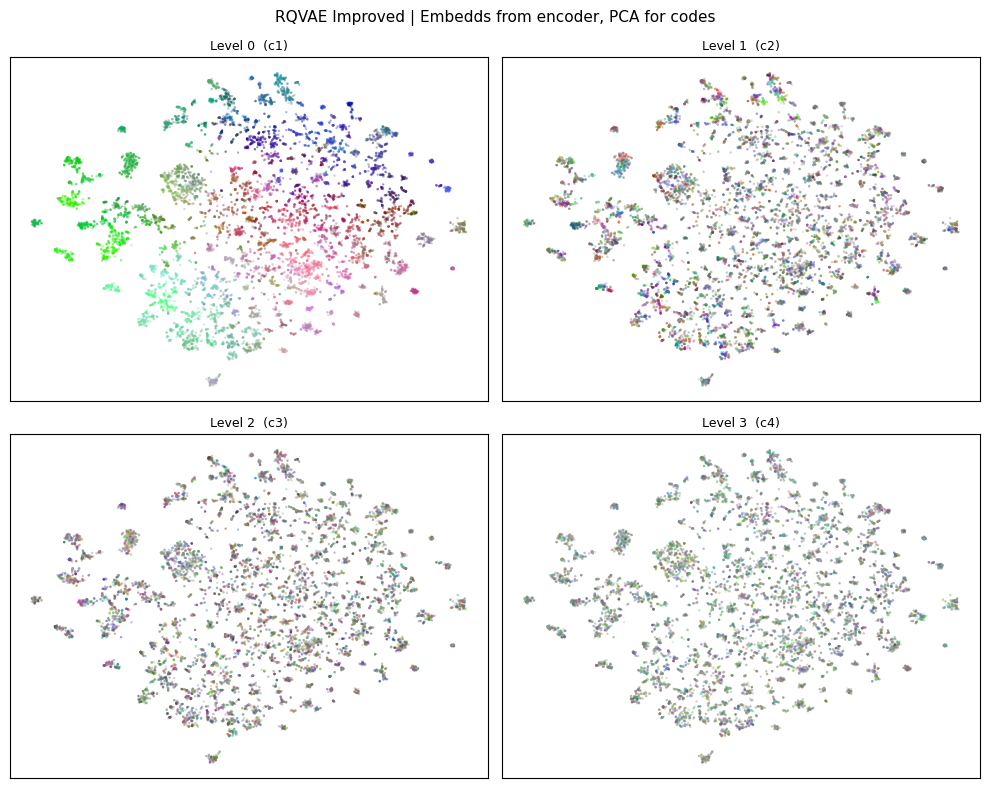

In [72]:

L = model_imp.n_layers
rows, cols = make_grid(L)

rgb_tables_imp = [make_rgb_table(model_imp, lvl) for lvl in range(L)]

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
fig.suptitle('RQVAE Improved | Embedds from encoder, PCA for codes', fontsize=11)
axs = axes.flatten()
for lvl in range(L):
    scatter_rgb(axs[lvl], proj_enc_imp, codes_imp[:, lvl],
                rgb_tables_imp[lvl], f'Level {lvl}  (c{lvl+1})')
for i in range(L, len(axs)):
    axs[i].axis('off')
plt.tight_layout()
plt.savefig('imp_vB_rgb.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14312\1961769201.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', len(cat_names))


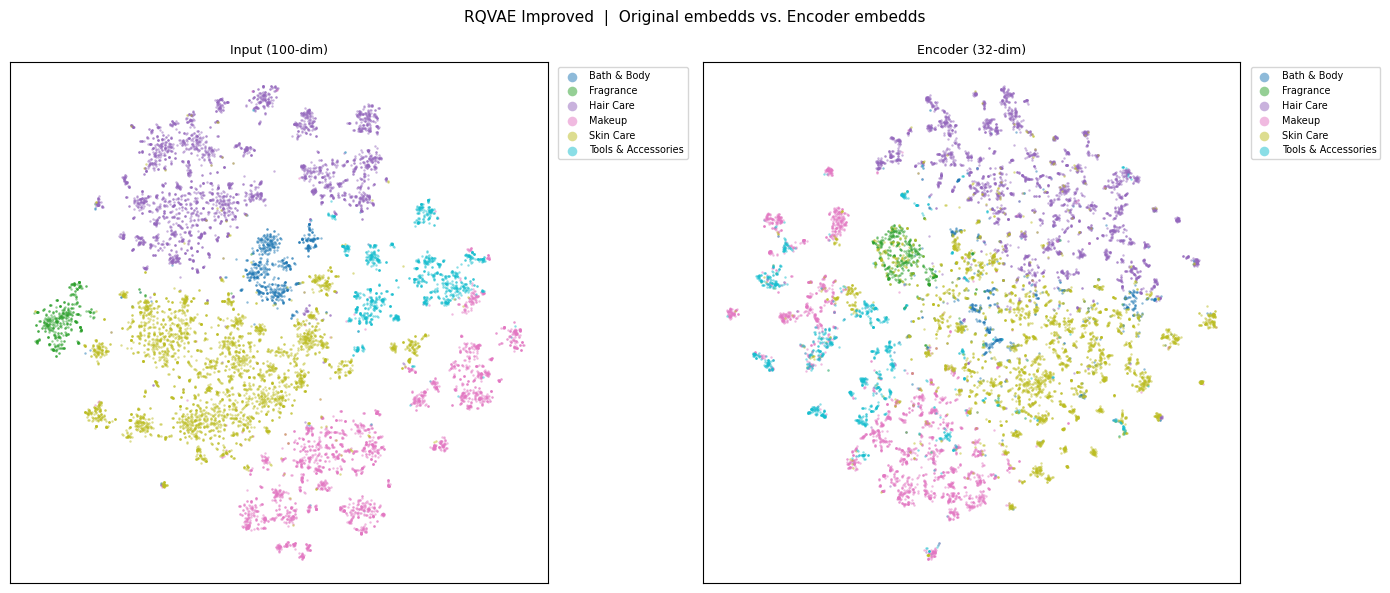

In [65]:
fig, (ax_in, ax_enc) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RQVAE Improved  |  Original embedds vs. Encoder embedds', fontsize=11)
scatter_categorical(ax_in,  proj_input,   cat_ids, cat_names, 'Input (100-dim)')
scatter_categorical(ax_enc, proj_enc_imp, cat_ids, cat_names, 'Encoder (32-dim)')
plt.tight_layout()
plt.savefig('imp_v3_category_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:

if model_anti is None:
    print('Anti model not loaded — skipping.')
else:
    print('RQVAE_Anti: collecting encoder embeddings...')
    enc_mat_anti, codes_anti = collect_enc_and_codes(model_anti, ds, device)
    proj_enc_anti = run_tsne(enc_mat_anti)
    print('Done.')

RQVAE_Anti: collecting encoder embeddings...
  t-SNE (12101, 32) → (N, 2)...
Done.


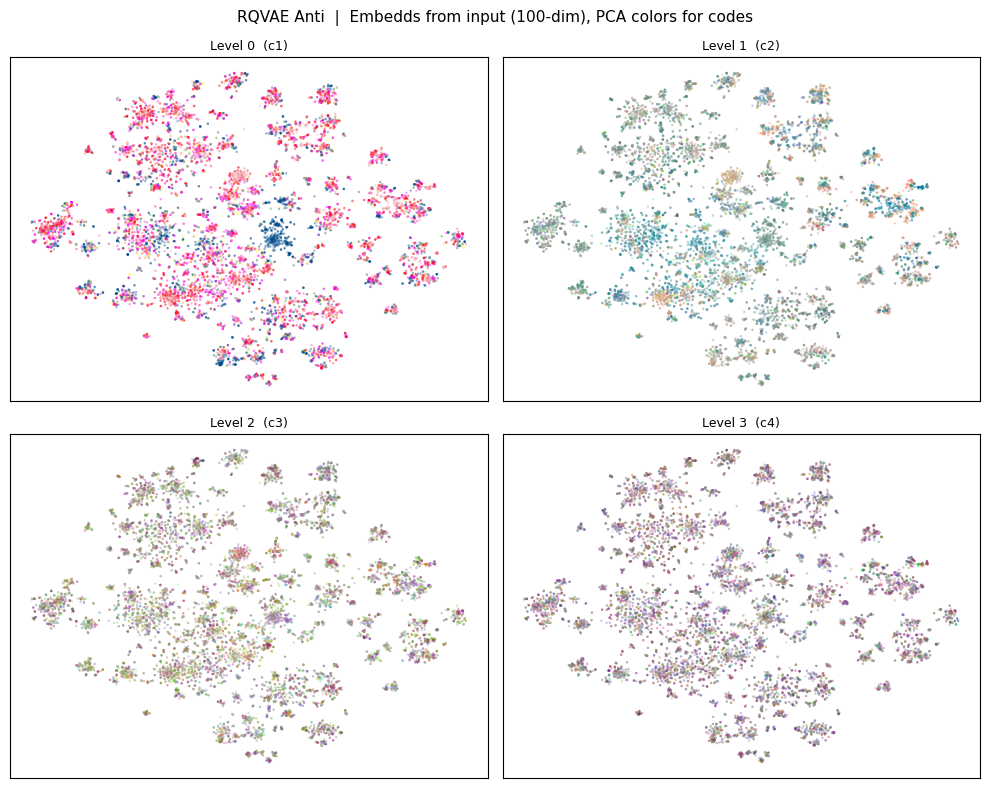

In [78]:

if model_anti is None:
    print('Anti model not loaded — skipping.')
else:
    L_a = model_anti.n_layers
    rows_a, cols_a = make_grid(L_a)
    rgb_tables_anti = [make_rgb_table(model_anti, lvl) for lvl in range(L_a)]

    fig, axes = plt.subplots(rows_a, cols_a, figsize=(5*cols_a, 4*rows_a))
    fig.suptitle('RQVAE Anti  |  Embedds from input (100-dim), PCA colors for codes', fontsize=11)
    axs = axes.flatten()
    for lvl in range(L_a):
        scatter_rgb(axs[lvl], proj_input, codes_anti[:, lvl], rgb_tables_anti[lvl], f'Level {lvl}  (c{lvl+1})')

    for i in range(L_a, len(axs)): axs[i].axis('off')
    plt.tight_layout()
    plt.savefig('anti_v1_input_by_code.png', dpi=150, bbox_inches='tight')
    plt.show()

   

    

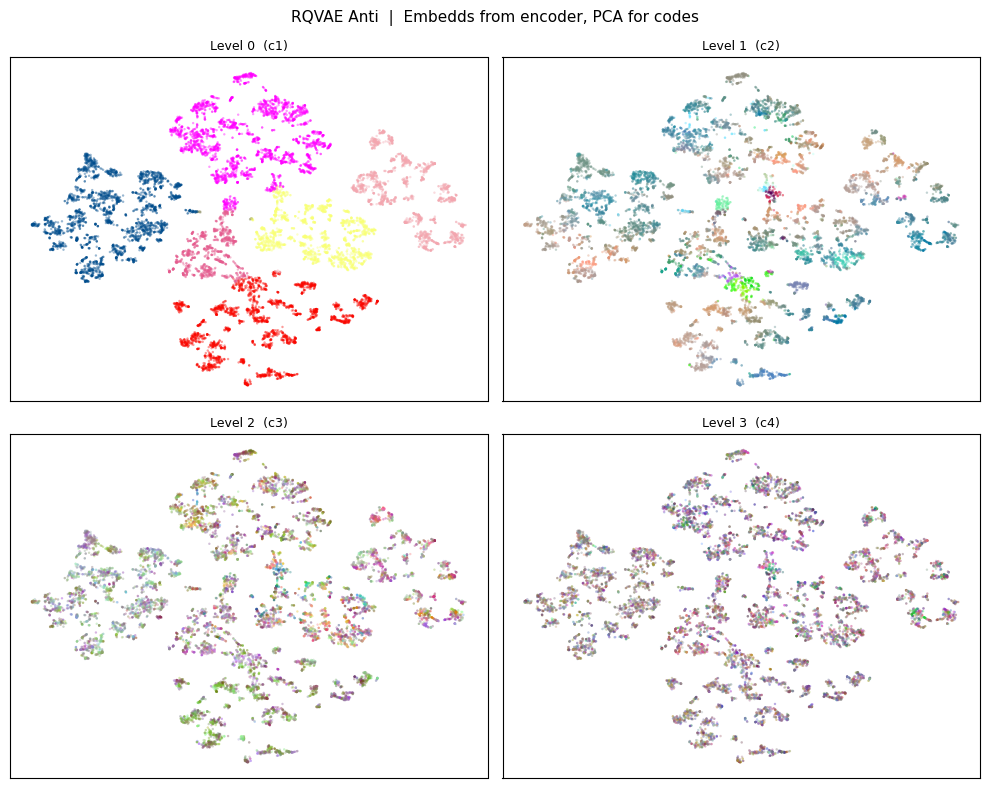

In [79]:
if model_anti is None:
    print('Anti model not loaded — skipping.')
else:

    L_a = model_anti.n_layers
    rows_a, cols_a = make_grid(L_a)

    rgb_tables_anti = [make_rgb_table(model_anti, lvl) for lvl in range(L_a)]

    fig, axes = plt.subplots(rows_a, cols_a, figsize=(5*cols_a, 4*rows_a))
    fig.suptitle('RQVAE Anti  |  Embedds from encoder, PCA for codes', fontsize=11)
    axs = axes.flatten()
    for lvl in range(L_a):
        scatter_rgb(axs[lvl], proj_enc_anti, codes_anti[:, lvl],
                    rgb_tables_anti[lvl], f'Level {lvl}  (c{lvl+1})')
    for i in range(L_a, len(axs)):
        axs[i].axis('off')
    plt.tight_layout()
    plt.savefig('anti_vB_rgb.png', dpi=150, bbox_inches='tight')
    plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14312\1961769201.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', len(cat_names))


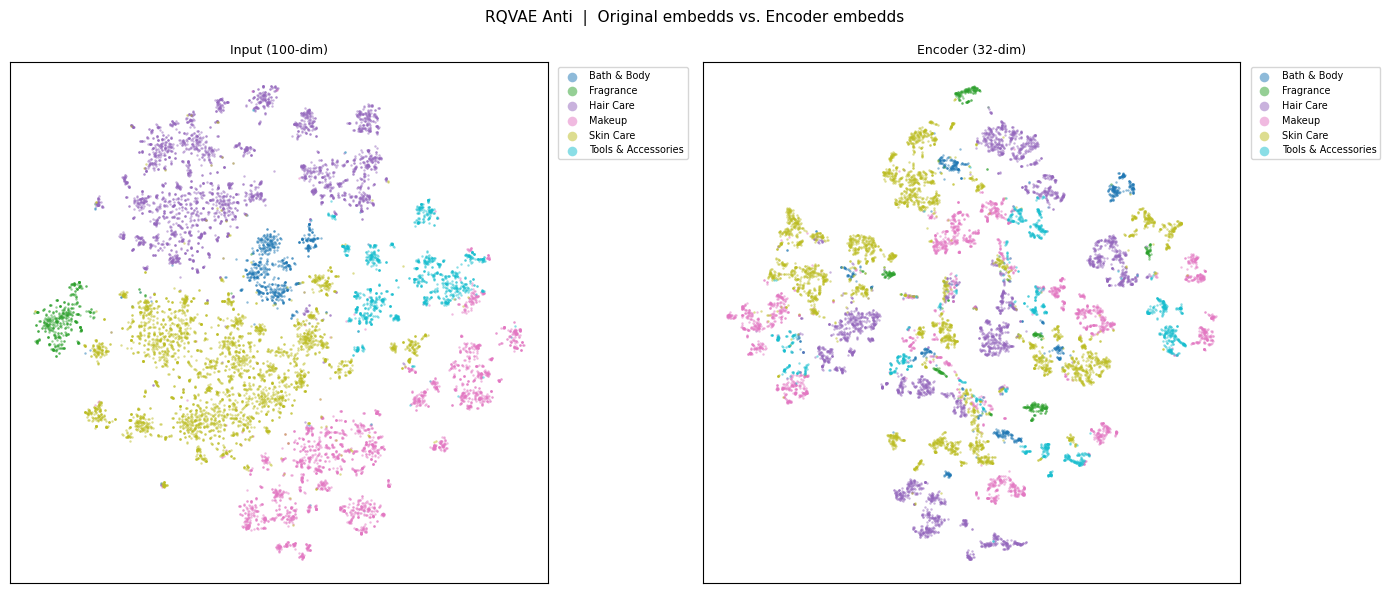

In [80]:
fig, (ax_in, ax_enc) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RQVAE Anti  |  Original embedds vs. Encoder embedds', fontsize=11)
scatter_categorical(ax_in,  proj_input,    cat_ids, cat_names, 'Input (100-dim)')
scatter_categorical(ax_enc, proj_enc_anti, cat_ids, cat_names, 'Encoder (32-dim)')
plt.tight_layout()
plt.savefig('anti_v3_category_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
